This is the baseline prediction done using Logistic Regression on only numerical features of Application train dataset. This is the first step to see, what kind of features we have to work with initially.

In [ ]:
# Importing required libraries
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,RocCurveDisplay,ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully.")
np.random.seed(42)

Libraries imported successfully.


# || Data Loading ||

In [ ]:
# loading and printing the dataset
application=pd.read_csv('/Users/rageshwer/Goal ML/Projects/Home_Credit_Default_Risk/data/raw/application_train.csv')
print(application.info())
application

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 325.2 MB
None


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# columns in the dataset and their respective datatypes
dictionary={
    'int64':[],
    'float64':[],
    'str':[]
}
for col in application.columns:
    dictionary[str(application[col].dtype)].append(col)
for key,val in dictionary.items():
    n=len(val)
    print(f"Total columns of {key} data type : {n}")
    i=0
    while(i+5<=n-1):
        print(val[i:i+5])
        i+=5
    print("_________________________________________________________________________________________________________")


Total columns of int64 data type : 41
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
['DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE']
['FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START']
['REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY']
['LIVE_CITY_NOT_WORK_CITY', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5']
['FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10']
['FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15']
['FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20']
_________________________________________________________________________________________________________
Total columns of float64 data type 

# || Data Inspection, Basic Cleaning ||

In [5]:
# missing values
missing_application=application.isna().sum()
missing_application=missing_application[missing_application>0].sort_values(ascending=False)
print(f"No of columns that have missing values : {len(missing_application)}")
print("___________________________________________________________")
print(missing_application)

No of columns that have missing values : 67
___________________________________________________________
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64


There are a lot of missing values in the datasets. Top features have more than 66% of missing values. First we will median impute the numerical columns and for categorical columns, mark as 'unknown' for initial scoring.<br>
We will be creating a copy of the dataset (application1) to check for a base line model with basic cleaning and no FE.
### Median imputing numeric columns:

In [6]:
application_1=application.copy()
numeric_cols=dictionary['int64']+dictionary['float64']
numeric_cols=[col for col in numeric_cols if col != 'TARGET']
application_1[numeric_cols] = (application_1[numeric_cols]
    .fillna(application_1[numeric_cols].median()))
application_1[numeric_cols].isna().sum().value_counts()

0    105
Name: count, dtype: int64

### Handling missing values in categorical column:
Currently, we will replace NULL with 'unknown' for initial model building and evaluation.

In [7]:
application_1[dictionary['str']]=application_1[dictionary['str']].fillna('unknown')
application_1[dictionary['str']].isna().sum().value_counts()

0    16
Name: count, dtype: int64

In [8]:
# checking for target class distribution
class_0=application_1['TARGET'].value_counts()[0]
class_1=application_1['TARGET'].value_counts()[1]
print("Distribution or Percentage of defaulters and non defaulters in the target variable :")
print(f"Class 0 (Non Defaulters) : {class_0/(class_0+class_1)*100:.2f}% \nClass 1 (Defaulters) : {class_1/(class_0+class_1)*100:.2f}%")

Distribution or Percentage of defaulters and non defaulters in the target variable :
Class 0 (Non Defaulters) : 91.93% 
Class 1 (Defaulters) : 8.07%


There is an imbalance in the dataset target variable.<br>

# || Splitting and Model building || 

We will use stratified sampling because of class imbalance in the target variable.

In [9]:
# splitting for train and test
X_app1,y_app1=application_1[numeric_cols],application_1['TARGET']
X_train_app1,X_test_app1,y_train_app1,y_test_app1=train_test_split(X_app1,y_app1,random_state=42,stratify=y_app1)

In [10]:
# scaling 
ss=StandardScaler()
X_train_app1_s=ss.fit_transform(X_train_app1)
X_test_app1_s=ss.transform(X_test_app1)

Model building and training:

In [11]:
log_reg=LogisticRegression(random_state=42)
log_reg.fit(X_train_app1_s,y_train_app1)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Evaluation:

Accuracy Score : 0.9192356721038528
Precision : 0.48
Recall : 0.005800837898807605
F1 Score : 0.011463142811654194
Area Under Curve Score : 0.7368868411611861


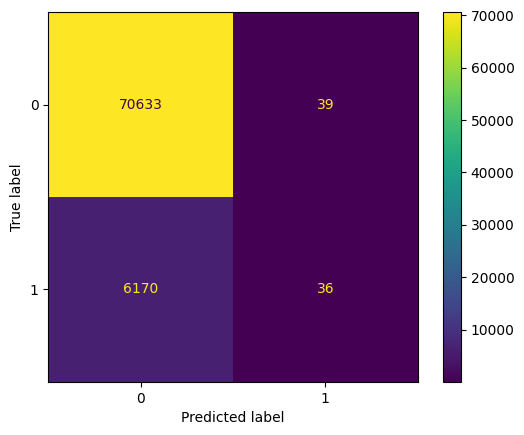

In [12]:
y_pred_app1=log_reg.predict(X_test_app1_s)
y_proba_app1=log_reg.predict_proba(X_test_app1_s)[:,1]
print(f"Accuracy Score : {accuracy_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
print(f"Precision : {precision_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
print(f"Recall : {recall_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
print(f"F1 Score : {f1_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
auc=roc_auc_score(y_true=y_test_app1,y_score=y_proba_app1)
print(f"Area Under Curve Score : {auc}")
cm=confusion_matrix(y_test_app1,y_pred_app1)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Now using class_weight = 'balanced' for log regression. This makes our model penalize error on minority class instead of minimising the errors and predicting all as non defaulters. So, after this, our precision should decrease and recall should increase. 

Accuracy Score : 0.6822758136267852
Precision : 0.15656337178617205
Recall : 0.6691911053818885
F1 Score : 0.25375779054136627
Area Under Curve Score : 0.7388555822394229


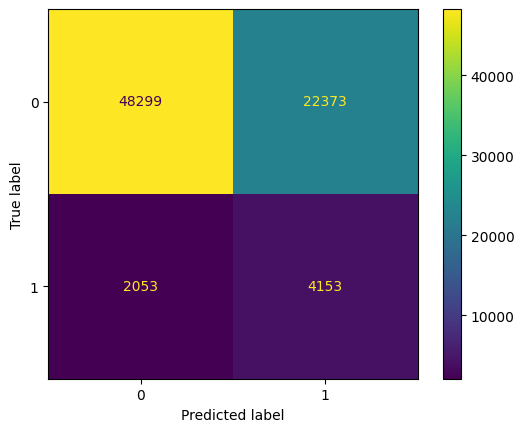

In [13]:
log_reg2=LogisticRegression(random_state=42,class_weight='balanced',max_iter=500)
log_reg2.fit(X_train_app1_s,y_train_app1)
y_pred_app1=log_reg2.predict(X_test_app1_s)
y_proba_app1=log_reg2.predict_proba(X_test_app1_s)[:,1]
print(f"Accuracy Score : {accuracy_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
print(f"Precision : {precision_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
print(f"Recall : {recall_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
print(f"F1 Score : {f1_score(y_pred=y_pred_app1,y_true=y_test_app1)}")
auc=roc_auc_score(y_true=y_test_app1,y_score=y_proba_app1)
print(f"Area Under Curve Score : {auc}")
cm=confusion_matrix(y_test_app1,y_pred_app1)
ConfusionMatrixDisplay(cm).plot()
plt.show()

We are more concerned about recall in a default prediction rather than accuracy, so this is actually a good base line model. So, the base line AUC score is :
### 0.73